#ISS projekt 2025/26 "Music search"
### Úvod
Skoro každý už někdy použil aplikace na vyhledávání hudby (Music Information Retrieval, MIR) - Shazaam a podobné. V tomto projektu si jednoduchou MIR aplikaci naprogramujete na základě toho, co jste se naučili v ISS.

### Data a cíl řešení
Vše je v https://www.fit.vut.cz/study/course/ISS/public/proj2025-26/
Budeme pracovat s WAV soubory (1 kanál, vzorkovací frekvence 16 kHz), máme pro Vás nachystáno následující:
* known.zip - soubor 706 desetisekundových zvukových klipů. Toto jsou známá audia, jsou v souborech 0.wav ... 705.wav
* valid.zip - soubor 50 testovacích pětisekundových klipů s klíčem, které audio patří ke kterému známému. Obsahuje 0.wav ... 49.wav a klíč key.txt
* login.zip - soubor 50 evaluačních pětisekundových klipů, *login* je Váš login. Obsahuje 0.wav až 49.wav. Klíče k němu máme my, budeme hodnotit, jak se Vám úloha povedla.

Dále je k disposici tento Py notebook, kde jsou nachystány funkce pro čtení audií a vyhodnocení.

Vaším úkolem je vyrobit a okomentovat funkci
* compute_similarity_matrix - vstupem je 50 neznámých audií, výstupem je matice s 50 řádky a 706 sloupci, udávající podobnosti neznámych audii k 706 známým. Větší číslo znamená větší podobnost.

Na **validačním setu**  si můžete oskórovat úspěšnost proti zadanému klíči (postup na to je dodán)

Na Vašem **osobním evaluačním setu** pak vyprodukujete matici podobností, textový výstup nám odevzdáte a budeme ho skórovat my.  

### Způsob vypracování
Projekt je možno řešit v Python notebooku, Matlab-u, Octave, Julii, jazyce C, Java nebo v libovolném jiném programovacím či skriptovacím jazyce. Je možné použít libovolné knihovny, kromě specializovaných knihoven pro MIR. Porgram nesmí volat externí cloudové služby. Použití AI modelů pro "pomoc" s projektem nezakazujeme, ale
* pokuste se o vlastní řešení, generovaný kód doporučujeme jako alternativu, výsedky porovnejte
* i AI generovanému kódu byste měli rozumět - to poznáme z protokolu.

Projekt se nezaměřuje na krásu programování, všechny konstanty, jména souborů, atd. je možné zadat "natvrdo", není nutné ošetřovat chybové stavy. Není nutné mít vše úhledně zabalené do funkcí, ale pomůže to. Podmínkou je, aby Váš program byl spustitelný na Google Colab nebo na standardní fakultní distribuci Windows nebo Linux.

Součástí vypracování je protokol, ve kterém popíšete, co jste dělali - viz níže.

### Doporučené postupy řešení
Úloha je totálně na Vás, Honzovo  řešení obsahuje velmi "prasácké" porovnávání realizované pomocí výpočtu funkce krátkodobé energie s 20ms rámci a se všemi možnými normalizacemi a použití přizpůsobeného filtru. Dosahuje Top 1 accuracy  32.0 %, Top 5 accuracy  44.0 %.

Lepší cesta bude asi parametrizovat signály pomocí spektrogramu, uvědomte si, že není možné přímé srovnání, protože známé signály mají 10s, neznámé 5s a dali jsme si pozor, abychom je vybrali z různých míst známých signálů a ještě přidali trochu šumu a filtrování. Rozhodně doporučujeme si pár příkladů **poslechnout** a během ladění zobrazovat signály, spektorgramy, průběhy podobností, atd - obrázky pak rádi uvidíme v protokolu.

Nad spektrogramy můžete dělat následující:
* rozhodně doporučujeme používat pouze amplitudovou složku.
* uvažte normalizaci (např. průměrným spektrem), abyste se vyhnuli vlivům filtrování.
* uvažte, zda používat i části spektrogramu na velmi nízkých a velmi vysokých frekvencích, kde není nic užitečného
* uvažte, zda používat spektorgram s plným rozlišením, nebo ho snížit použitém širokých frekvenčních kanálů (definovaných lineárně nebo např. pomocí Mel-frekveční osy).

Pro srovnání uvažte:
* posouvání testovacího spektrogramu přes refernční (ale to je hodně hloupá metoda...)
* korelaci
* připůsobené filtrování (což je to samé jako korelace)
* Zájemci mohou zkusit detekci maxim ve spektru a jejich konfigurace a la  Shazaam, viz https://www.ee.columbia.edu/~dpwe/papers/Wang03-shazam.pdf
* cokoliv jiného, tvořivosti a nápaditosti se meze nekladou
Cokoliv vyvinete vždy oskórujte a zjistěte, zda se 1-best a 5-best přesnost na validační sadě posunula oproti Vaší předchozí verzi.

**Cílem projektu není 100% úspěšnost**, ale **pochopení a popis  toho, co děláte.** Do protokolu uvádějte co vás vedlo k vaší volbě, z jakých zdrojů jste čerpali a jakých výsledků jste dosáhli. Stručně komentujte i postupy nevedoucí k žádanému cíli.

### Odevzdání
**Termín odevzdání je první pondělí po konci semestru - 15.12.2025, 23:59**
Projekt se odevzdává prostřednictvím informačního systému. Odevzdání bude sestávat ze tří souborů:
  1. **Protokol** ve kterém popíšete, jak jste problém řešili a k jakým výsledkům jste se dopracovali. Protokol bude obsahovat
  * Na začátku Vaše jméno a login...
  * Odůvodnění zvoleného řešení
  * Popis implementace, případných problémů a jejich řešení
  * K jakým výsledkům jste se dopracovali na validační sadě

  Součástí protokolu budou doprovodné obrázky nebo grafy. Pokud použijete obrázky a grafy, které neprodukuje váš program, ale jsou převzaté (např. ilustrativní obrázek, schéma) citujte v souladu s citační etikou. Pokud budete pracovat v Python Notebooku, tvořte protokol textovými poli v notebooku, nestačí jen komentáře v kódu. Protokol bude ve formátu **PDF**. Upozorňujeme, že **pokud bude protokol obsahovat jen kód a výstupy Vašeho kódu, ale žádný popis řešení,  komentáře a hodnocení, bude hodnocen nulou nebo málo body.**

  Pokud budete psát česky nebo slovensky, nazvěte prosím soubor s protokolem  *login.pdf*, kde 'login' je Váš login. Pokud anglicky, pak *login_e.pdf*. Za psaní anglicky nejsou žádné zvláštní body (ani plus ani minus), ale *_e* nám ulehčí rozdělování Vašich řešení opravovačům.

  2. **Program**, kterým jste v rámci řešení projektu vytvořili. Program bude přehledný a rozumně komentovaný. Program bude vypisovat hodnoty a produkovat obrázky uvedené v protokolu.
  * Pokud je program Python notebook na Google Colab, odevzdáte místo programu jen textový soubor s jedinou řádkou - URL Vašeho Python Notebooku. Ten musí být pro opravovače **čitelný** a **spustitelný**.
  * Pokud program bude rozdělen do více souborů, nebo pro jeho spuštění poskytnete návod v souboru README.txt, pak všechny části zabalte do jednoho zip souboru.

  3. **Výsledek - textový soubor eval.txt**. Prosíme neměňte jeho formát, použijte export přiložený k tomuto Python notebooku. Pokud budete pracovat v Google Colab, soubor stáhnete klikem na ikonku složky v levém sloupci dole, pak soubor standardně stáhnete. Budeme používat stejnou skórovací funkci, jakou máte k disposici Vy. Pokud budete experimentovat s více metodami, prosím odevzejte pouze jeden soubor eval.txt vyprodukovaný tou nejlepší metodou a výsledky ostatních metod okomentujte a srovnejte v protokolu.

### Dotazy
Dotazy budou řešeny prostřednictvím diskuzního fóra zřízeného za tímto účelem na kartě předmětu. Bude nastaveno automatické odebírání, takže příspěvky přidané do fóra by měli vidět všichni.

### Toto zadání ...
... prosím neexportujte do protokolu, ať nemusíme 580x číst to samé. Raději zkontrolujte, zda máte na začátku Vaše jméno a login. Děkujeme!


In [1]:
# needed
import os
import re
import soundfile as sf
from IPython.display import Audio
from IPython.display import display
import numpy as np
# recommended ...
from scipy import signal
from scipy.io import wavfile
from scipy.signal import spectrogram
from scipy.ndimage import maximum_filter
from collections import defaultdict
import pickle
from scipy.fft import fft, ifft, fftfreq
import scipy.io
import matplotlib.pyplot as plt
from matplotlib import cm
from typing import Optional
import time
from tqdm import tqdm

In [2]:
# SETTINGS
LOGIN = "239026" 

SAMPLE_RATE = 16000
NFFT = 2048
FRAME_DURATION = 0.1  # in seconds

NPERFRAME = int(SAMPLE_RATE * FRAME_DURATION)
NOVERLAP = NPERFRAME // 8

# parameters for peak extraction
NEIGHBORHOOD_SIZE = (25, 25)  # size of the neighborhood to consider for max filtering
PEAKS_TO_KEEP = 256  # maximum number of peaks to keep for each spectrogram

# fingerprinting parameters
TARGET_ZONE_OFFSET = 0.1  # seconds
TARGET_ZONE_DURATION = 1.8 # seconds
TARGET_ZONE_FREQUENCY_BAND = 4000  # Hz

# parameters for fingerprint storage
LOAD_FROM_FILE = True  # if True, load existing file-based storage of fingerprints, 
                        # else use in-memory dictionary that has to be rebuilt each time        
SAVE_TO_FILE = True  # if True, save fingerprint database to file after building

FILE_NAME = "fingerprint.pkl"

In [3]:
# # read data
# if not (os.path.exists("known") and os.path.exists("valid") and os.path.exists(LOGIN)):
#     for name in ("known.zip", "valid.zip", LOGIN + ".zip"):
#         file = "https://www.fit.vut.cz/study/course/ISS/public/proj2025-26/" + name
#         !rm $name
#         !wget $file
#         !unzip -o -q $name

In [4]:
# read data windows version

# import urllib.request
# import zipfile
# import os

# if not (os.path.exists("known") and os.path.exists("valid") and os.path.exists(LOGIN)):
#     for name in ("known.zip", "valid.zip", LOGIN + ".zip"):
#         file_url = "https://www.fit.vut.cz/study/course/ISS/public/proj2025-26/" + name
        
#         # Remove existing file if it exists
#         if os.path.exists(name):
#             os.remove(name)
#             print(f"Removed existing {name}")
        
#         # Download file
#         print(f"Downloading {name}...")
#         try:
#             urllib.request.urlretrieve(file_url, name)
#             print(f"Downloaded {name}")
#         except Exception as e:
#             print(f"Error downloading {name}: {e}")
#             continue
        
#         # Extract file
#         print(f"Extracting {name}...")
#         try:
#             with zipfile.ZipFile(name, 'r') as zip_ref:
#                 zip_ref.extractall()
#             print(f"Extracted {name}")
#         except Exception as e:
#             print(f"Error extracting {name}: {e}")

In [5]:
# print parameters
print("==============PARAMETERS============")
print(f"CWD = {os.getcwd()}" )
print(f"SAMPLE RATE = {SAMPLE_RATE}" )
print(f"NFFT = {NFFT}" )
print(f"FRAME DURATION (s) = {FRAME_DURATION}" )
print(f"SAMPLES PER FRAME = {NPERFRAME}" )
print(f"OVERLAP (SAMPLES) = {NOVERLAP}" )
print(f"NEIGHBORHOOD SIZE = {NEIGHBORHOOD_SIZE}" )
print(f"PEAKS TO KEEP = {PEAKS_TO_KEEP}" )
print("===============STORAGE=============")
print(f"LOAD FROM FILE = {LOAD_FROM_FILE}" )
print(f"SAVE TO FILE = {SAVE_TO_FILE}" )
print(f"FILE NAME = {FILE_NAME}" )

==============PARAMETERS============
CWD = c:\TomasJ\ISS-course\proj
SAMPLE RATE = 16000
NFFT = 2048
FRAME DURATION (s) = 0.1
SAMPLES PER FRAME = 1600
OVERLAP (SAMPLES) = 200
NEIGHBORHOOD SIZE = (25, 25)
PEAKS TO KEEP = 256
===============STORAGE=============
LOAD FROM FILE = True
SAVE TO FILE = True
FILE NAME = fingerprint.pkl


In [6]:
# load the known data - the function returns a big matrix with all the signals
def load_data (S, dirname, count, no_samples):
  ii = 0
  for one in np.arange(count):
    S[ii], Fs = sf.read(dirname + "/" + str(one) + ".wav")
    ii = ii+1

# load known data
N_known = 706; duration_known = 10; 
no_samples_known = SAMPLE_RATE * duration_known
known_signals=np.zeros([N_known, no_samples_known]); 
load_data(known_signals, "known", N_known, no_samples_known)
display(Audio(known_signals[45], rate=SAMPLE_RATE))

# load validation data
N_valid = 50; duration_valid = 5; 
no_samples_valid = SAMPLE_RATE * duration_valid
valid_signals=np.zeros([N_valid, no_samples_valid]); 
load_data(valid_signals, "valid", N_valid, no_samples_valid)
display(Audio(valid_signals[45], rate=SAMPLE_RATE))

# load test data
N_eval = 50; duration_eval = 5;
no_samples_eval = SAMPLE_RATE * duration_eval
eval_signals=np.zeros([N_eval, no_samples_eval]); 
load_data(eval_signals, "239026", N_eval, no_samples_eval)
display(Audio(eval_signals[45], rate=SAMPLE_RATE))

In [7]:
# SPECTROGRAM RELATED FUNCTIONS

#spectrogram
def my_spectrogram(signal):
    """
    Compute spectrogram of the given signal. Uses scipy.signal spectrogram function.
    """
    return spectrogram(signal, fs=SAMPLE_RATE, nperseg=NPERFRAME, noverlap=NOVERLAP, nfft=NFFT)

def plot_spectrogram(f, t, Sxx, peaks=None, ax=None, vmin=-160):
    """
    Plot spectrogram with optional peaks overlay.
    
    Parameters:
    - f: frequency array
    - t: time array
    - Sxx: spectrogram power array
    - peaks: optional list of peaks (freq_idx, time_idx, magnitude)
    - ax: optional matplotlib axis object. If None, creates new figure
    
    Returns:
    - mesh: the pcolormesh object (useful for adding colorbar)
    """
    Sxx_log = 10 * np.log10(Sxx + 1e-20)  # Convert to dB scale
    
    # Create new figure if ax not provided
    if ax is None:
        plt.figure(figsize=(10, 4))
        ax = plt.gca()
    
    # Plot spectrogram
    mesh = ax.pcolormesh(t, f, Sxx_log, shading='gouraud', cmap=cm.inferno, vmin=vmin)
    
    # Plot peaks AFTER the spectrogram so they appear on top
    if peaks is not None:
        peak_freqs = peaks[:, 0]
        peak_times = peaks[:, 1]
        ax.scatter(peak_times, peak_freqs, c='cyan', s=10, marker='x', linewidths=1)
    
    ax.set_ylabel('Frequency [Hz]')
    ax.set_xlabel('Time [s]')
    ax.set_title('Spectrogram')
    ax.set_xlim(min(t), max(t))
    
    # Only show the plot if we created a new figure
    if ax is None:
        cbar = plt.colorbar(mesh)
        cbar.set_label('Power spectral density [dB]', rotation=270, labelpad=15)
        plt.show()
    
    return mesh

#extract_peaks
def extract_peaks(f, t,Sxx, filter_size= NEIGHBORHOOD_SIZE, peaks_to_keep=PEAKS_TO_KEEP):
    """Extracts peaks from a spectrogram using local maximum filtering."""
    # Apply local maximum filter
    local_max = maximum_filter(Sxx, size=filter_size)
    
    # Find where the spectrogram equals the local maximum (these are the real peaks)
    peak_mask = (Sxx == local_max)

    # get peak coordinates and magnitudes
    freq_idx, time_idx = np.where(peak_mask)
    magnitudes = Sxx[freq_idx, time_idx]
    # Sort peaks by magnitude in descending order
    sorted_mag_idx = np.flip(np.argsort(magnitudes))
    
    npeaks = len(sorted_mag_idx)
    # print(f"Found {npeaks} peaks in the spectrogram.")

    # Apply limit to number of peaks
    if npeaks > peaks_to_keep:
        # print(f"Using only {peaks_to_keep} peaks.")
        sorted_mag_idx = sorted_mag_idx[0:peaks_to_keep]


    freq_idx = freq_idx[sorted_mag_idx]
    time_idx = time_idx[sorted_mag_idx]
    # magnitudes = magnitudes[sorted_mag_idx]

    # Combine everything into list of tuples
    peaks_idx = np.zeros([len(sorted_mag_idx),2], dtype=int)
    peaks_idx[:,0] = freq_idx  
    peaks_idx[:,1] = time_idx
    
    peaks = np.zeros([len(sorted_mag_idx),2], dtype=float)
    peaks[:,0] = f[freq_idx]
    peaks[:,1] = t[time_idx]
    
    return peaks_idx, peaks

In [8]:
#target_zone
def target_zone_search(anchor: np.ndarray, peaks: np.ndarray):
    """Finds peaks within the target zone defined relative to the anchor peak."""
    target_zone_peaks = []
    anchor_freq, anchor_time = anchor
    
    # Define target zone boundaries
    time_start = anchor_time + TARGET_ZONE_OFFSET
    time_end = time_start + TARGET_ZONE_DURATION
    freq_limit_upper = anchor_freq + TARGET_ZONE_FREQUENCY_BAND/2
    freq_limit_lower = anchor_freq - TARGET_ZONE_FREQUENCY_BAND/2
    target_zone = np.array([time_start, time_end, freq_limit_lower, freq_limit_upper])

    # Search for peaks within the target zone
    for peak in peaks:
        peak_freq, peak_time = peak
        if (time_start <= peak_time <= time_end) and (freq_limit_lower <= peak_freq <= freq_limit_upper):
            target_zone_peaks.append(peak)

    # Convert list to numpy array for easier manipulation
    target_zone_peaks = np.array(target_zone_peaks)
    
    return target_zone_peaks, target_zone

#hash_generation
def generate_hashes(peaks, song_index: Optional[int] = None):
    """Generates fingerprint hashes from the list of peaks (constellation map). 
    For registration song_index must be provided and for identification leave song_index as None."""

    num_peaks = peaks.shape[0]
    n = np.arange(0, num_peaks)
    hash_list = []

    # for each anchor peak find target zone peaks and generate hashes
    for anchor_idx in n:
        anchor = peaks[anchor_idx]
        target_zone_peaks, _ = target_zone_search(anchor, peaks)

        if target_zone_peaks.size == 0:  # no peaks in target zone
            continue
        
        # for each peak in target zone generate hash in the form (hash, t1, song_index)
        for target_peak in target_zone_peaks:
            freq1 = int(anchor[0])
            freq2 = int(target_peak[0])
            t1 = int(anchor[1] * 100)             # convert to centiseconds  
            t2 = int(target_peak[1] * 100)        # convert to centiseconds
            delta_t = t2 - t1
            hash_value = hash((freq1, freq2, delta_t))

            if song_index is not None:
                hash_list.append((hash_value, t1, song_index))
            else:
                hash_list.append((hash_value, t1))

    return hash_list

#fingerprint_generation
def generate_fingerprint(signal, song_index: Optional[int] = None):
    """Generates fingerprint hashes for a single signal. 
    For registration song_index must be provided and for identification leave song_index as None."""
    f, t, Sxx = my_spectrogram(signal)
    _, peaks = extract_peaks(f, t, Sxx)
    return generate_hashes(peaks, song_index=song_index)

In [9]:
# FINGERPRINT DB FUNCTIONS

#build_database
def build_fingerprint_database(known_signals, load_from_file: Optional[bool] = False, save_to_file: Optional[bool] = True, filename: Optional[str] ="fingerprint.pkl"):
    """Build hash database from all known songs."""
    
    fingerprint_db = defaultdict(list)  # {hash_value: [(time_offset, song_index)]}
    
    # if file-based storage is used, try to load existing database, else build new one
    if load_from_file:
        if os.path.exists(filename):
            print("Loading fingerprint database from file...")
            fingerprint_db = load_fingerprint_db_pickle(filename)
            print(f"Total unique hashes: {len(fingerprint_db)}")
            return fingerprint_db
        else:
            print("Fingerprint database file not found. Building new database...")

    start_time = time.time()
    
    # TQDM for progress bar :) 
    for idx in tqdm(range(len(known_signals)), desc="Building database", unit="song"):
        hashes = generate_fingerprint(known_signals[idx], song_index=idx)
        
        # add hashes to the database
        for hash_value, time_offset, song_index in hashes:
            fingerprint_db[hash_value].append((time_offset, song_index))
    
    end_time = time.time()
    print(f"\nDatabase built in {end_time - start_time:.2f} seconds")
    print(f"Total unique hashes: {len(fingerprint_db)}")
    
    # save database to file
    if save_to_file:
        save_fingerprint_db_pickle(fingerprint_db, filename=filename)

    return fingerprint_db

#save_database
def save_fingerprint_db_pickle(fingerprint_db, filename: Optional[str] = "fingerprint.pkl"):
    """Save fingerprint database using pickle."""
    with open(filename, 'wb') as f:
        pickle.dump(fingerprint_db, f)
    print(f"Fingerprint database saved to {filename}")

#load_database
def load_fingerprint_db_pickle(filename: str ="fingerprint.pkl"):
    """Load fingerprint database from pickle file."""
    with open(filename, 'rb') as f:
        fingerprint_db = pickle.load(f)
    print(f"Fingerprint database loaded from {filename}")
    print(f"Total unique hashes: {len(fingerprint_db)}")
    return fingerprint_db

In [10]:
# RECOGNITION FUNCTIONS AND EVALUATION FUNCTIONS

#recognize_signal
def recognize_signal(input_signal, fingerprint_db):
    """Recognize the song from the given signal using the fingerprint database."""
    query_hashes = generate_fingerprint(input_signal)
    matches = defaultdict(int)  # {song_index: count_of_matching_hashes}

    # for each hash in the signal, check if it exists in the database
    for hash_value, _ in query_hashes:
        if hash_value in fingerprint_db:
            entries = fingerprint_db[hash_value]
            for _, song_index in entries:
                matches[song_index] += 1
    
    return matches

#comp_similarity_matrix
def compute_similarity_matrix(signals, fingerprint_db , N_signals: int, N_known: int):
    """Compute similarity matrix between valid and known signals."""
    similarities = np.zeros((N_signals, N_known), dtype=int)

    # for each validation/test signal, create scores and fill the similarity matrix
    for signal_id in tqdm(range(N_signals) , desc="Computing similarities", unit="validation signal"):
        recognized_song = recognize_signal(signals[signal_id], fingerprint_db)
        for song_index, match_count in recognized_song.items():
            similarities[signal_id, song_index] = match_count

    return similarities

def eval(scores, key):
    indices = np.flip(np.argsort(scores), axis=-1) # we want highest to lowest ...
    #print(scores[0,key[0]], key[0], indices)
    top1acc = np.sum(key == indices[:,0]) / indices.shape[0]
    top5acc = 0
    for ii in range(5):
        top5acc += np.sum(key == indices[:,ii])
    top5acc /=  indices.shape[0]
    return top1acc, top5acc


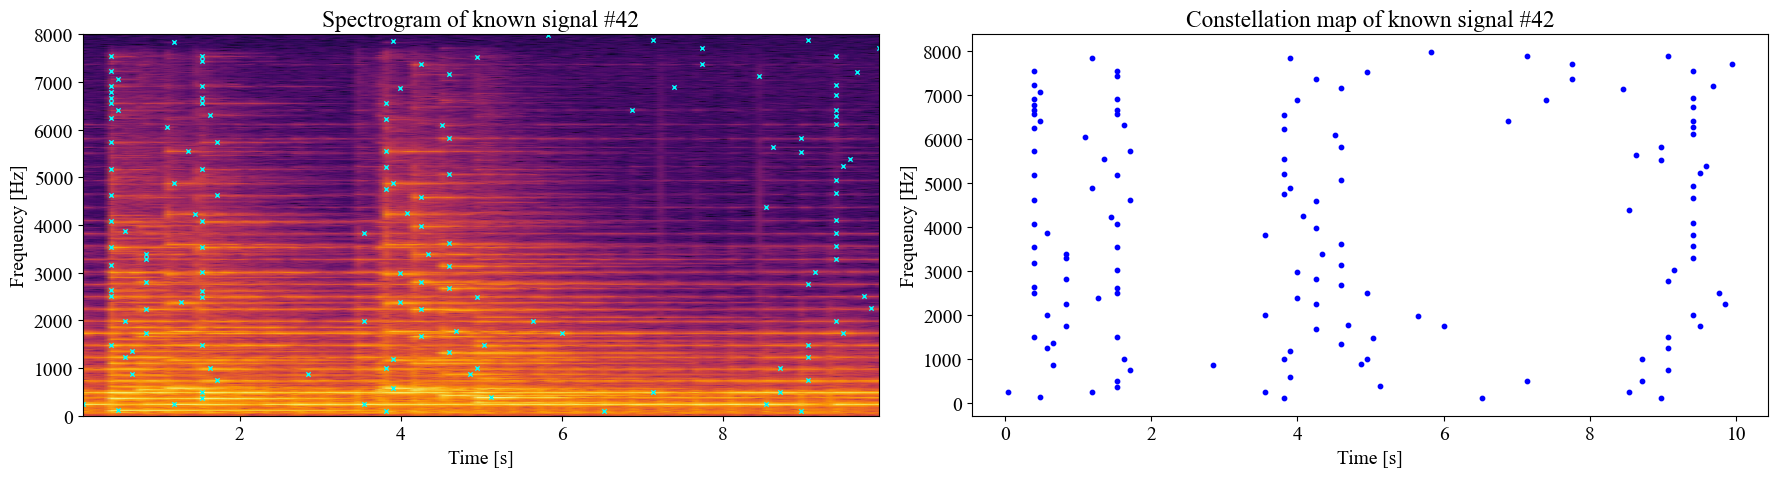

In [11]:
# PICTURES FOR REPORT
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 14  # optional: set font size

song_index = 42  # index of the song to visualize
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(18, 5))
# First spectrogram
f1, t1, Sxx1 = my_spectrogram(known_signals[song_index])

peaks1_idx,  peaks1 = extract_peaks(f1, t1, Sxx1)
mesh1 = plot_spectrogram(f1, t1, Sxx1, peaks1, ax=ax1)
ax1.set_title(f'Spectrogram of known signal #{song_index}')
# ax1.set_aspect('auto') 
# plt.colorbar(mesh1, ax=ax1, label='PSD [dB]')

# second spectrogram
ax2.scatter(peaks1[:,1], peaks1[:,0], c='blue', s=10, marker='o', linewidths=1)
ax2.set_title(f'Constellation map of known signal #{song_index}')
# ax2.set_aspect('auto')
ax2.set_ylabel('Frequency [Hz]')
ax2.set_xlabel('Time [s]')
# plt.savefig('spectrogram.pdf', format='pdf', bbox_inches='tight', dpi=300)

plt.tight_layout()




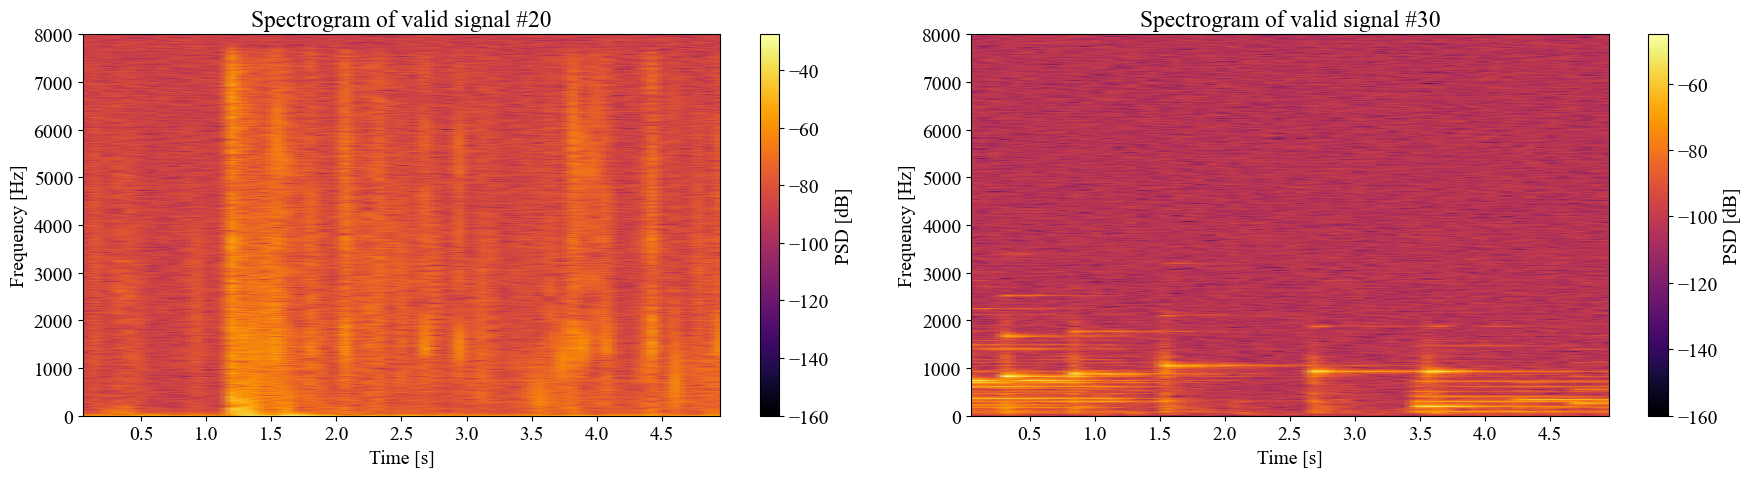

In [12]:
song_index = 20  # index of the song to visualize
fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(18, 5))  # Create figure with 2 subplots

# First spectrogram - plot in ax1
f1, t1, Sxx1 = my_spectrogram(valid_signals[song_index])
mesh1 = plot_spectrogram(f1, t1, Sxx1, ax=ax1)

ax1.set_title(f'Spectrogram of valid signal #{song_index}')
ax1.set_xticks(np.arange(0.5, 5, 0.5))
ax1.set_aspect('auto') 
plt.colorbar(mesh1, ax=ax1, label='PSD [dB]')

# song_index = 30

# f2, t2, Sxx2 = my_spectrogram(valid_signals[song_index])
# mesh2 = plot_spectrogram(f2, t2, Sxx2, ax=ax2)

# ax2.set_title(f'Spectrogram of valid signal #{song_index}')
# ax2.set_xticks(np.arange(0.5, 5, 0.5))
# ax2.set_aspect('auto') 
# plt.colorbar(mesh2, ax=ax2, label='PSD [dB]')

song_index = 30

f3, t3, Sxx3 = my_spectrogram(valid_signals[song_index])
mesh3 = plot_spectrogram(f3, t3, Sxx3, ax=ax3)

ax3.set_title(f'Spectrogram of valid signal #{song_index}')
ax3.set_xticks(np.arange(0.5, 5, 0.5))
ax3.set_aspect('auto') 
plt.colorbar(mesh3, ax=ax3, label='PSD [dB]')
plt.tight_layout()
# plt.savefig('valid_spectrograms.pdf', format='pdf', bbox_inches='tight', dpi=300)

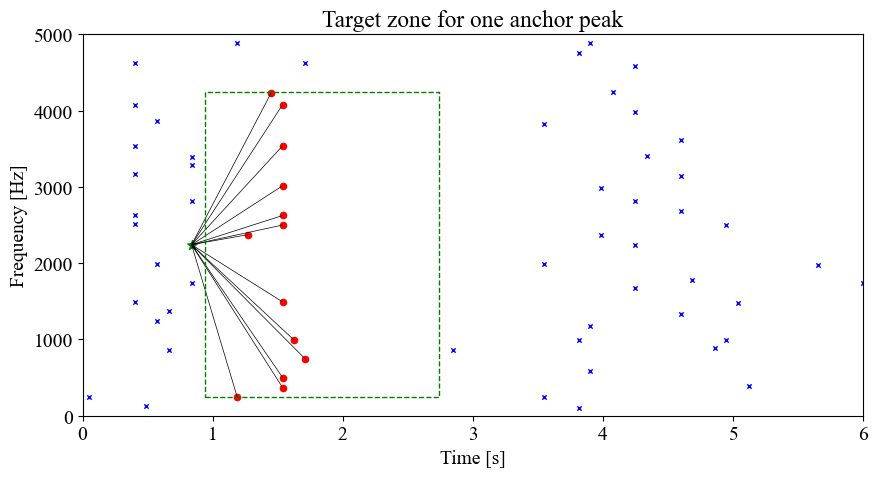

In [13]:
fig2, ax3 = plt.subplots(1, 1, figsize=(9, 5))

anchor_id  = 38

# Filter peaks to show only in desired range (0-6s, 0-5000Hz)
time_mask = (peaks1[:,1] >= 0) & (peaks1[:,1] <= 6)
freq_mask = (peaks1[:,0] >= 0) & (peaks1[:,0] <= 5000)
display_mask = time_mask & freq_mask
filtered_peaks = peaks1[display_mask]

ax3.scatter(filtered_peaks[:,1], filtered_peaks[:,0], c='blue', s=10, marker='x', linewidths=1)

target_zone_peaks, target_zone = target_zone_search(peaks1[anchor_id], peaks1)

# Filter target zone peaks for display
if target_zone_peaks.size > 0:
    target_time_mask = (target_zone_peaks[:,1] >= 0) & (target_zone_peaks[:,1] <= 6)
    target_freq_mask = (target_zone_peaks[:,0] >= 0) & (target_zone_peaks[:,0] <= 5000)
    target_display_mask = target_time_mask & target_freq_mask
    filtered_target_peaks = target_zone_peaks[target_display_mask]
    
    if filtered_target_peaks.size > 0:
        ax3.scatter(filtered_target_peaks[:,1], filtered_target_peaks[:,0], c='red', s=20, marker='o', linewidths=1)
        # plot black line from anchor to each target zone peak (only filtered ones)
        for peak in filtered_target_peaks:
            ax3.plot([peaks1[anchor_id,1], peak[1]], [peaks1[anchor_id,0], peak[0]], 'k-', linewidth=0.5)

# Show anchor peak if it's in range
if (peaks1[anchor_id,1] >= 0 and peaks1[anchor_id,1] <= 6 and 
    peaks1[anchor_id,0] >= 0 and peaks1[anchor_id,0] <= 5000):
    ax3.scatter(peaks1[anchor_id,1], peaks1[anchor_id,0], c='green', s=50, marker='*', linewidths=1)

# Clip target zone rectangle to display range
target_zone_clipped = target_zone.copy()
target_zone_clipped[0] = max(target_zone[0], 0)  # time_start
target_zone_clipped[1] = min(target_zone[1], 6)  # time_end
target_zone_clipped[2] = max(target_zone[2], 0)  # freq_lower
target_zone_clipped[3] = min(target_zone[3], 5000)  # freq_upper

ax3.plot([target_zone_clipped[0], target_zone_clipped[1], target_zone_clipped[1], target_zone_clipped[0], target_zone_clipped[0]],
         [target_zone_clipped[2], target_zone_clipped[2], target_zone_clipped[3], target_zone_clipped[3], target_zone_clipped[2]], 'g--', linewidth=1)

ax3.set_xlabel('Time [s]')
ax3.set_ylabel('Frequency [Hz]')
ax3.set_title(f'Target zone for one anchor peak')

# Set axis limits to desired range
ax3.set_xlim(0, 6)
ax3.set_ylim(0, 5000)

plt.tight_layout()
# plt.savefig('targetzone.pdf', format='pdf', bbox_inches='tight', dpi=300)

In [14]:
#here comes the computation and evaluation on validation data ...

key = np.loadtxt("valid/key.txt", delimiter = ',', usecols=(1), dtype ='int')

fingerprint_db = build_fingerprint_database(known_signals, load_from_file=LOAD_FROM_FILE, save_to_file=SAVE_TO_FILE, filename=FILE_NAME)

start_time = time.time()
scores_matrix = compute_similarity_matrix(valid_signals, fingerprint_db , N_valid, N_known)
end_time = time.time()
print(f"Similarity matrix computed in {end_time - start_time:.2f} seconds")
# print("Similarity matrix shape:", scores_matrix.shape)
#
top1, top5 = eval(scores_matrix, key)
print("Top 1 accuracy ", top1 * 100, "%, Top 5 accuracy ", top5 * 100, "%" )

# find predictions for each validation song
predictions = np.argmax(scores_matrix, axis=1)  
match_counts = np.max(scores_matrix, axis=1)   

# compare with key
correct_mask = (predictions == key)
correct_predictions = predictions[correct_mask]
print("==================================================")
print(f"Correct predictions: {len(correct_predictions)} out of {N_valid}")
for i in range(N_valid):
    print(f"Validation song {i}: Predicted = {predictions[i]}, Actual = {key[i]}, Matches = {match_counts[i]}")
incorrect_predictions = predictions[~correct_mask]
print("==================================================")
print(f"Incorrect predictions: {len(incorrect_predictions)} out of {N_valid}")
for i in range(N_valid):
    if predictions[i] != key[i]:
        print(f"Validation song {i}: Predicted = {predictions[i]}, Actual = {key[i]}, Matches = {match_counts[i]}")

Loading fingerprint database from file...
Fingerprint database loaded from fingerprint.pkl
Total unique hashes: 1230803
Total unique hashes: 1230803


Computing similarities: 100%|██████████| 50/50 [00:00<00:00, 115.74validation signal/s]

Similarity matrix computed in 0.44 seconds
Top 1 accuracy  98.0 %, Top 5 accuracy  98.0 %
Correct predictions: 49 out of 50
Validation song 0: Predicted = 182, Actual = 182, Matches = 59
Validation song 1: Predicted = 308, Actual = 308, Matches = 28
Validation song 2: Predicted = 338, Actual = 338, Matches = 21
Validation song 3: Predicted = 496, Actual = 496, Matches = 84
Validation song 4: Predicted = 670, Actual = 670, Matches = 46
Validation song 5: Predicted = 240, Actual = 240, Matches = 27
Validation song 6: Predicted = 69, Actual = 69, Matches = 116
Validation song 7: Predicted = 649, Actual = 649, Matches = 32
Validation song 8: Predicted = 515, Actual = 515, Matches = 124
Validation song 9: Predicted = 529, Actual = 529, Matches = 152
Validation song 10: Predicted = 281, Actual = 281, Matches = 45
Validation song 11: Predicted = 532, Actual = 532, Matches = 77
Validation song 12: Predicted = 380, Actual = 380, Matches = 226
Validation song 13: Predicted = 588, Actual = 588, M

In [15]:
# NOW on my data!

# load your data - ALREADY DONE ABOVE
# N_eval = 50; duration_eval = 5; no_samples_eval = SAMPLE_RATE * duration_eval
# eval_signals=np.zeros([N_eval, no_samples_eval]); load_data(eval_signals, LOGIN, N_eval, no_samples_eval)
#display(Audio(valid_signals[45], rate=Fs))

scores_matrix = compute_similarity_matrix(eval_signals, fingerprint_db , N_eval, N_known)
#np.savetxt("eval.txt", scores_matrix)

# # to download it in Google Colab click on the folder icon in the left column, find eval.txt and download it as usually.


Computing similarities: 100%|██████████| 50/50 [00:00<00:00, 142.05validation signal/s]


In [16]:
eval_scores = np.loadtxt("eval.txt")
pred_key = np.loadtxt("predictions_key.txt", delimiter = ',', usecols=(1), dtype ='int')

top1_eval, top5_eval = eval(eval_scores, pred_key)
print("Top 1 accuracy ", top1_eval * 100, "%, Top 5 accuracy ", top5_eval * 100, "%" )

# Najdi predikce pro každou validační píseň
predictions_eval = np.argmax(eval_scores, axis=1)  # Index nejvyšší hodnoty v každém řádku
match_counts_eval = np.max(eval_scores, axis=1)    # Nejvyšší počet shod

# Porovnej s klíčem
correct_mask_eval = (predictions_eval == pred_key)
correct_predictions_eval = predictions_eval[correct_mask_eval]
print("==================================================")
print(f"Correct predictions: {len(correct_predictions_eval)} out of {N_valid}")
for i in range(N_valid):
    print(f"Validation song {i}: Predicted = {predictions_eval[i]}, Actual = {pred_key[i]}, Matches = {match_counts_eval[i]}")
incorrect_predictions_eval = predictions_eval[~correct_mask_eval]
print("==================================================")
print(f"Incorrect predictions: {len(incorrect_predictions_eval)} out of {N_valid}")
for i in range(N_valid):
    if predictions_eval[i] != pred_key[i]:
        print(f"Validation song {i}: Predicted = {predictions_eval[i]}, Actual = {pred_key[i]}, Matches = {match_counts_eval[i]}")

Top 1 accuracy  100.0 %, Top 5 accuracy  100.0 %
Correct predictions: 50 out of 50
Validation song 0: Predicted = 640, Actual = 640, Matches = 28.0
Validation song 1: Predicted = 265, Actual = 265, Matches = 26.0
Validation song 2: Predicted = 335, Actual = 335, Matches = 19.0
Validation song 3: Predicted = 324, Actual = 324, Matches = 255.0
Validation song 4: Predicted = 360, Actual = 360, Matches = 281.0
Validation song 5: Predicted = 400, Actual = 400, Matches = 352.0
Validation song 6: Predicted = 464, Actual = 464, Matches = 23.0
Validation song 7: Predicted = 626, Actual = 626, Matches = 209.0
Validation song 8: Predicted = 397, Actual = 397, Matches = 72.0
Validation song 9: Predicted = 126, Actual = 126, Matches = 124.0
Validation song 10: Predicted = 563, Actual = 563, Matches = 169.0
Validation song 11: Predicted = 571, Actual = 571, Matches = 207.0
Validation song 12: Predicted = 487, Actual = 487, Matches = 8.0
Validation song 13: Predicted = 431, Actual = 431, Matches = 24

In [34]:
### experimental implementation of time offset matching


#recognize_signal_offs
def recognize_signal_time_offset(input_signal, fingerprint_db):
    """Recognize the song from the given signal using the fingerprint database with time offset alignment."""
    query_hashes = generate_fingerprint(input_signal)
    
    # {song_id: {time_offset_diff: count}}
    offset_matches = defaultdict(lambda: defaultdict(int))
    
    for query_hash_value, query_time in query_hashes:
        if query_hash_value in fingerprint_db:
            for db_time, song_id in fingerprint_db[query_hash_value]:
                
                #calculate time diff between db hash and query hash
                time_diff = db_time - query_time
                
                time_diff_rounded = round(time_diff / 10) * 10

                #Count the occurrence of this time offset for particular song
                offset_matches[song_id][time_diff_rounded] += 1
    
    # For each song, find the most common time offset
    best_matches = {}
    for song_id, offsets in offset_matches.items():
        # Most common offset = likely position of query in the song
        best_offset = max(offsets, key=offsets.get)  #get offset with max count 
        match_count = offsets[best_offset]
        best_matches[song_id] = (match_count, best_offset)
    
    return best_matches

#comp_similarity_matrix_offs
def compute_similarity_matrix_time_offsets(signals, fingerprint_db , N_signals: int, N_known: int):
    """Compute similarity matrix between valid and known signals."""
    similarities = np.zeros((N_signals, N_known), dtype=int)
    time_offsets = np.zeros((N_signals, N_known), dtype=int)

    # for each validation/test signal, create scores and fill the similarity matrix
    for signal_id in tqdm(range(N_signals) , desc="Computing similarities", unit="validation signal"):
        recognized_songs = recognize_signal_time_offset(signals[signal_id], fingerprint_db)

        for song_id, (match_count, time_offset) in recognized_songs.items():
            similarities[signal_id, song_id] = match_count
            time_offsets[signal_id, song_id] = time_offset 
    return similarities, time_offsets

In [35]:
start_time = time.time()
scores_matrix, time_offsets = compute_similarity_matrix_time_offsets(valid_signals, fingerprint_db , N_valid, N_known)
end_time = time.time()
print(f"Similarity matrix computed in {end_time - start_time:.2f} seconds")

top1, top5 = eval(scores_matrix, key)
print("Top 1 accuracy ", top1 * 100, "%, Top 5 accuracy ", top5 * 100, "%" )

# find predictions for each validation song
predictions = np.argmax(scores_matrix, axis=1)  # Index of the highest value in each row
match_counts = np.max(scores_matrix, axis=1)    # Highest number of matches

# find time offsets for each prediction
predicted_time_offsets = np.zeros(N_valid, dtype=int)
for i in range(N_valid):
    predicted_time_offsets[i] = time_offsets[i, predictions[i]]

# compare with key
correct_mask = (predictions == key)
correct_predictions = predictions[correct_mask]

print(f"Correct predictions: {len(correct_predictions)} out of {N_valid}")
print("==================================================")
for i in range(N_valid):
    time_shift_sec = predicted_time_offsets[i] / 100.0  # Convert centiseconds to seconds
    print(f"Validation song {i}: Predicted = {predictions[i]}, Actual = {key[i]}, "
          f"Matches = {match_counts[i]}, Time shift = {time_shift_sec:.2f} s")

incorrect_predictions = predictions[~correct_mask]
print("==================================================")
print(f"Incorrect predictions: {len(incorrect_predictions)} out of {N_valid}")
for i in range(N_valid):
    if predictions[i] != key[i]:
        time_shift_sec = predicted_time_offsets[i] / 100.0
        print(f"Validation song {i}: Predicted = {predictions[i]}, Actual = {key[i]}, "
              f"Matches = {match_counts[i]}, Time shift = {time_shift_sec:.2f} s")


Computing similarities: 100%|██████████| 50/50 [00:00<00:00, 145.35validation signal/s]

Similarity matrix computed in 0.35 seconds
Top 1 accuracy  98.0 %, Top 5 accuracy  98.0 %
Correct predictions: 49 out of 50
Validation song 0: Predicted = 182, Actual = 182, Matches = 39, Time shift = 3.70 s
Validation song 1: Predicted = 308, Actual = 308, Matches = 20, Time shift = 0.40 s
Validation song 2: Predicted = 338, Actual = 338, Matches = 19, Time shift = 1.60 s
Validation song 3: Predicted = 496, Actual = 496, Matches = 84, Time shift = 4.60 s
Validation song 4: Predicted = 670, Actual = 670, Matches = 42, Time shift = 3.20 s
Validation song 5: Predicted = 240, Actual = 240, Matches = 26, Time shift = 2.60 s
Validation song 6: Predicted = 69, Actual = 69, Matches = 116, Time shift = 4.90 s
Validation song 7: Predicted = 649, Actual = 649, Matches = 21, Time shift = 3.70 s
Validation song 8: Predicted = 515, Actual = 515, Matches = 64, Time shift = 4.90 s
Validation song 9: Predicted = 529, Actual = 529, Matches = 150, Time shift = 2.00 s
Validation song 10: Predicted = 281,